# IOAI field

## Setup

In [1]:
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import sys, os
sys.path.append(os.path.join('..', 'grading'))

from core import (
    FieldConfig, EvalConfig, evaluate_model,
    render_heatmap, render_masks,
    make_batch, count_params, ConstModel
)

SEED = 2026

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

# fake config for trivial solutions
eval_cfg_fake = EvalConfig(
    n_per_region=512,
    seed=SEED,
    range_mode="p99",
    entropy_runs=10,
    entropy_mode="std",
    enforce_unit_interval=True,
    entropy_min=-2026,
    entropy_max=2026,
    max_params=20260,
    param_penalty=0.5,
    ignore_torch_check=True  # this checks if model is from Torch
)

eval_cfg = EvalConfig(
    n_per_region=512,
    seed=SEED,
    range_mode="p99",
    entropy_runs=10,
    entropy_mode="std",
    enforce_unit_interval=True,
    entropy_min=-2026,
    entropy_max=2026,
    max_params=20260,
    param_penalty=0.5,
)

/app/notebooks/IOAI-2026/Individual-Contest/6_IOAI_Field/code/grading


---
## Visualization

Three visualisations are produced:

- **Heatmap (in logarithmic scale)**
- **Region masks** — one image per each letter
- **Heatmap** without the first I letter

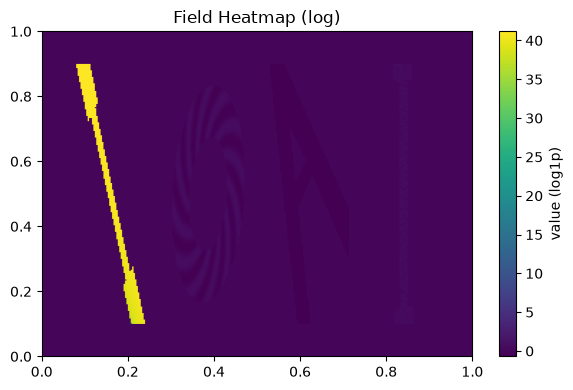

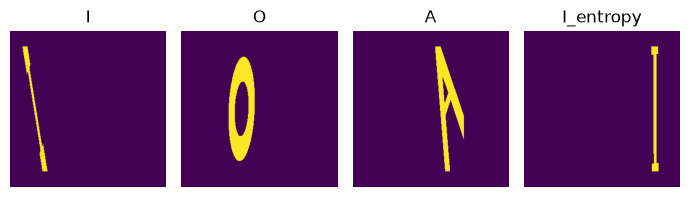

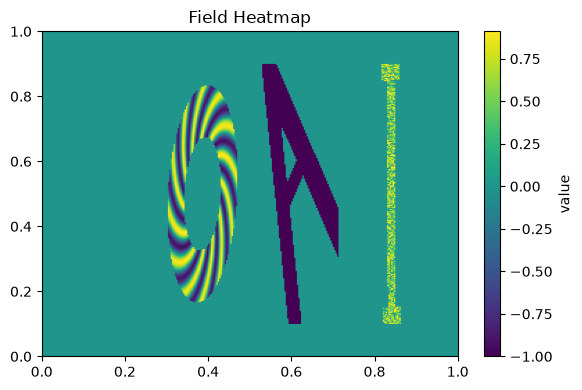

In [2]:
# The grader OVERLAYS the hidden leaderboard config onto data/train_config/ and
# retrains this notebook on it. So load the config from disk (do NOT hardcode it) --
# that is what makes your training code generalise to the hidden evaluation field.

TRAIN_DIR = Path("data/public/train_config")
LB_A_DIR = Path("data/private/leaderboard_a_config")
LB_B_DIR = Path("data/private/leaderboard_b_config")
cfg_file = TRAIN_DIR / "field_config.json" # local validation
cfg_file = LB_A_DIR / "field_config.json" # lb a
cfg_file = LB_B_DIR / "field_config.json" # lb b

with open(cfg_file) as f:
    cfg = FieldConfig(**json.load(f))

_ = render_heatmap(cfg, resolution=300, log_scale=True)
_ = render_masks(cfg, resolution=300)
_ = render_heatmap(cfg, resolution=300, log_scale=False, exclude=("I",))

---
## Trivial solutions (not working for submission)

Before training a network it is useful to know what *trivial* strategies can achieve.


### Trivial 1 — Predict zero everywhere

Background region is perfectly predicted, `I` and `O` have some scores due to the scale normalisation.

In [3]:
scores = evaluate_model(ConstModel(0), cfg, eval_cfg_fake)
print(scores["__explain__"])

[I]
  I: n=512, mae=4.91326e+17, scale=9.29334e+17.
  score = 1 - min(mae/scale, 1) = 1 - min(4.91326e+17/9.29334e+17, 1) = 0.471314.

[O]
  O: n=512, mae=0.588079, scale=1.82863.
  score = 1 - min(mae/scale, 1) = 1 - min(0.588079/1.82863, 1) = 0.678405.

[A]
  A: n=512, mae=1, scale=0.
  constant target => using scale=1.0.
  score = 1 - min(mae/1.0, 1) = 0.

[I_entropy]
  I_entropy: n=512, runs=10, mode=std.
  Rule: if any run is outside [-2026,2026], point score=0.
  Final score = mean(point scores) = 0.

[bg]
  bg: n=512, mae=0, scale=0.1.
  score = 1 - min(mae/scale, 1) = 1 - min(0/0.1, 1) = 1.

[param multiplier]
  Params: skipped (non-torch model).

[total]
  Total: weighted mean of region scores * 100 = 42.9944.


### Trivial 2 — Predict $-1$ everywhere

**A** region perfectly predicted

In [4]:
scores = evaluate_model(ConstModel(-1), cfg, eval_cfg_fake)
print(scores["__explain__"])

[I]
  I: n=512, mae=4.91326e+17, scale=9.29334e+17.
  score = 1 - min(mae/scale, 1) = 1 - min(4.91326e+17/9.29334e+17, 1) = 0.471314.

[O]
  O: n=512, mae=1.02842, scale=1.82863.
  score = 1 - min(mae/scale, 1) = 1 - min(1.02842/1.82863, 1) = 0.437601.

[A]
  A: n=512, mae=0, scale=0.
  constant target => using scale=1.0.
  score = 1 - min(mae/1.0, 1) = 1.

[I_entropy]
  I_entropy: n=512, runs=10, mode=std.
  Rule: if any run is outside [-2026,2026], point score=0.
  Final score = mean(point scores) = 0.

[bg]
  bg: n=512, mae=1, scale=0.1.
  score = 1 - min(mae/scale, 1) = 1 - min(1/0.1, 1) = 0.

[param multiplier]
  Params: skipped (non-torch model).

[total]
  Total: weighted mean of region scores * 100 = 38.1783.


---
## Baseline Solution

In [5]:
from custom_model import CustomModel
from tqdm import tqdm
# Reset before model construction so rerunning earlier notebook cells does not
# change initialization or dropout randomness.
seed_everything(SEED)

model = CustomModel(hidden=[64]*3, dropout=0.1)
model.train()
print('params:', count_params(model))

optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer, 0.5)
epochs = 8000
batch_size = 256
record = 0.0
for epoch in tqdm(range(1, epochs + 1)):
    xy, y = make_batch(
        batch_size,
        cfg,
        exclude_regions=('I', 'O'),
        stratified=True,
        seed=SEED + epoch,
    )
    xy_t = torch.tensor(xy, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)

    optimizer.zero_grad()
    pred = model(xy_t)
    loss = (torch.abs(pred - y_t) ** 1.5).mean()
    loss.backward()
    optimizer.step()

    if epoch % 50 == 0:
        scores = evaluate_model(model, cfg, eval_cfg)
        print(f"epoch {epoch:03d} | loss={loss.item():.6g} | total={scores['total_score']:.2f}")
        if scores['total_score'] > record:
            record = scores['total_score']
            torch.save(model, 'model.pt') # model selection
    #if epoch % 2000 == 0:
    #    scheduler.step()
model = torch.load('model.pt', weights_only=False)
scores = evaluate_model(model, cfg, eval_cfg)
print(scores['__explain__'])
# 59.8736 on LB A / 58.6266 on LB B
# [64] * 3 + dropout 0.1 + 2000 epochs: 59.2002 on local validation
# [64] * 3 + dropout 0.1 + 2000 epochs: ~52 on local validation
# [64] * 3 + dropout 0.1 + 2000 epochs + exclude regions ('I', 'O'): 65.3846 (63.7486 A / 62.0965 B)
# [64] * 3 + dropout 0.1 + 8000 epochs / batch size 256 + exclude regions ('I', 'O'): 65.1619
# [64] * 3 + dropout 0.1 + 8000 epochs bs 256 + exclude regions ('I', 'O') + power 1.5 in loss: 67.3192 (66.6640 A / 64.7382 B)


params: 8577


  1%|          | 65/8000 [00:01<01:58, 66.69it/s]

epoch 050 | loss=0.0626897 | total=42.61


  1%|▏         | 112/8000 [00:01<01:34, 83.59it/s]

epoch 100 | loss=0.059396 | total=42.38


...

epoch 7900 | loss=0.0178681 | total=64.74


100%|█████████▉| 7974/8000 [01:31<00:00, 94.44it/s] 

epoch 7950 | loss=0.0258647 | total=63.34


100%|██████████| 8000/8000 [01:32<00:00, 86.90it/s] 


epoch 8000 | loss=0.0143216 | total=62.77
[I]
  I: n=512, mae=4.91326e+17, scale=9.29334e+17.
  score = 1 - min(mae/scale, 1) = 1 - min(4.91326e+17/9.29334e+17, 1) = 0.471314.

[O]
  O: n=512, mae=0.588097, scale=1.82863.
  score = 1 - min(mae/scale, 1) = 1 - min(0.588097/1.82863, 1) = 0.678395.

[A]
  A: n=512, mae=0.0956652, scale=0.
  constant target => using scale=1.0.
  score = 1 - min(mae/1.0, 1) = 0.904335.

[I_entropy]
  I_entropy: n=512, runs=10, mode=std.
  Rule: if any run is outside [-2026,2026], point score=0.
  Final score = mean(point scores) = 0.266206.

[bg]
  bg: n=512, mae=0.0083338, scale=0.1.
  score = 1 - min(mae/scale, 1) = 1 - min(0.0083338/0.1, 1) = 0.916662.

[param multiplier]
  Params: 8577 < 20260 => no penalty.

[total]
  Total: weighted mean of region scores * 100 = 64.7382.


---
## Save the model — REQUIRED

The grader loads `model.pt` and scores it. Save your trained model as a whole `nn.Module` (not a `state_dict`).


In [6]:
import torch
torch.save(model, "model.pt")
print("saved model.pt")


saved model.pt
